In [929]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import os
import joblib

In [930]:
df = pd.read_csv('../datasets/data_compramostucoche.csv', sep=';', encoding='utf-8')
df.head()

,marca_nombre,marca_id,version_id_catalogo,titulo_anuncio,registro,km,cambio,combustible,cv,precio
0,Kia,425,3457.0,Kia cee'd 1.6 CRDi,06/2014,17222,Manual,Diésel,128,12599
1,Kia,425,3554.0,Kia Sorento 1.6 TGDI Plug-in Hybrid,04/2024,32462,Automático,Híbrido,265,40999
2,Peugeot,670,6159.0,Peugeot 3008 2.0 Blue-HDi,07/2018,78068,Manual,Diésel,150,17299
3,Mercedes-Benz,570,NaN,Mercedes-Benz Clase GLA GLA 250e,02/2024,19060,Automático,Híbrido,218,39999
4,Citroen,190,1551.0,Citroen C4 Cactus 1.6 Blue-HDi,10/2016,94982,Manual,Diésel,100,9399


In [931]:
df = df.rename(columns={
    'marca_nombre': 'make',
    'km': 'kms',
})

In [932]:
df.isnull().sum()

make                     0
marca_id                 0
version_id_catalogo    418
titulo_anuncio           0
registro                 0
kms                      0
cambio                   0
combustible              0
cv                       0
precio                   0
dtype: int64

In [933]:
data_null = df[df['version_id_catalogo'].isnull()]

data_null['make'].value_counts()

make
Mercedes-Benz     179
BMW                93
Seat               53
Citroen            50
Ford                9
Audi                7
Mazda               5
Cupra               3
Renault             2
Land Rover          2
Peugeot             2
Suzuki              1
Toyota              1
DS Automobiles      1
Volkswagen          1
Hyundai             1
MG                  1
Ssangyong           1
Fiat                1
Opel                1
Kia                 1
Jeep                1
Nissan              1
Mitsubishi          1
Name: count, dtype: int64

In [934]:
df_modelos = pd.read_csv('../datasets/seed_modelos.csv', sep=';', encoding='utf-8')
df_versiones = pd.read_csv('../datasets/seed_versiones.csv', sep=';', encoding='utf-8')
df_marcas = pd.read_csv('../datasets/seed_marcas.csv', sep=';', encoding='utf-8')

In [935]:
df_catalogo_completo = df_versiones.merge(df_modelos, on='modelo_id')
df_catalogo_completo = df_catalogo_completo.merge(df_marcas, on='marca_id')
df_catalogo_completo

,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth
...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr


In [936]:
df_catalogo_completo.rename(columns={
    'version_id': 'version_id_catalogo'
})

,version_id_catalogo,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth
...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr


In [937]:
df_catalogo_completo['titulo_anuncio'] = df_catalogo_completo['nombre_marca'] + ' ' + df_catalogo_completo['nombre_modelo'] + ' ' + df_catalogo_completo['clave_motor']

In [938]:
df_catalogo_completo['titulo_anuncio'] = df_catalogo_completo['titulo_anuncio'].str.lower()
df['titulo_anuncio'] = df['titulo_anuncio'].str.lower()

In [939]:
df_catalogo_completo

,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca,titulo_anuncio
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth,abarth 124 spider 1.4 turbo
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth,abarth 124 spider gt
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth,abarth 500 1.4 turbo
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth,abarth 500e electric drive 114 kw
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth,abarth 500e cabrio electric drive 114 kw
...,...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr,zeekr 7x single motor 310 kw
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr,zeekr 001 electric drive 200 kw
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr,zeekr 001 electric drive 400 kw
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr,zeekr x electric drive 200 kw


In [940]:
df['version_id_catalogo'] = df['version_id_catalogo'].astype('Int64')

In [941]:
df_final = df.merge(df_catalogo_completo, how='left', on='titulo_anuncio')
df_final

,make,marca_id_x,version_id_catalogo,titulo_anuncio,registro,kms,cambio,combustible,cv,precio,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id_y,nombre_marca
0,Kia,425,3457,kia cee'd 1.6 crdi,06/2014,17222,Manual,Diésel,128,12599,3458.0,694.0,1.6 CRDi,cee'd 1.6 CRDi,cee'd,cee'd,425.0,Kia
1,Kia,425,3554,kia sorento 1.6 tgdi plug-in hybrid,04/2024,32462,Automático,Híbrido,265,40999,3554.0,723.0,1.6 TGDI Plug-in Hybrid,Sorento 1.6 TGDI Plug-in Hybrid,Sorento,Sorento,425.0,Kia
2,Peugeot,670,6159,peugeot 3008 2.0 blue-hdi,07/2018,78068,Manual,Diésel,150,17299,6159.0,1127.0,2.0 Blue-HDi,3008 2.0 Blue-HDi,3008,3008,670.0,Peugeot
3,Mercedes-Benz,570,<NA>,mercedes-benz clase gla gla 250e,02/2024,19060,Automático,Híbrido,218,39999,4645.0,898.0,GLA 250e,GLA-Klasse GLA 250e,GLA-Klasse,Clase GLA,570.0,Mercedes-Benz
4,Citroen,190,1551,citroen c4 cactus 1.6 blue-hdi,10/2016,94982,Manual,Diésel,100,9399,1551.0,277.0,1.6 Blue-HDi,C4 Cactus 1.6 Blue-HDi,C4 Cactus,C4 Cactus,190.0,Citroen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3109,Peugeot,670,6017,peugeot 308 1.6 e-hdi,10/2013,104553,Manual,Diésel,115,8999,6019.0,1111.0,1.6 e-HDi,308 1.6 e-HDi,308,308,670.0,Peugeot
3110,Seat,790,6861,seat exeo 2.0 tdi,08/2012,153084,Manual,Diésel,120,7499,6861.0,1231.0,2.0 TDI,Exeo 2.0 TDI,Exeo,Exeo,790.0,Seat
3111,Peugeot,670,6135,peugeot 2008 1.2 puretech,09/2018,57320,Manual,Gasolina,130,12699,6138.0,1126.0,1.2 PureTech,2008 1.2 PureTech,2008,2008,670.0,Peugeot
3112,MINI,580,5136,mini cabrio one,03/2018,55773,Manual,Gasolina,102,17999,5136.0,953.0,One,Cabrio One,Cabrio,Cabrio,580.0,MINI


In [942]:
df_final.isnull().sum()

make                     0
marca_id_x               0
version_id_catalogo    418
titulo_anuncio           0
registro                 0
kms                      0
cambio                   0
combustible              0
cv                       0
precio                   0
version_id              88
modelo_id               88
clave_motor             88
nombre_completo         88
id_web                  88
nombre_modelo           88
marca_id_y              88
nombre_marca            88
dtype: int64

In [943]:
df_final.drop(columns=['make','marca_id_x', 'version_id_catalogo', 'titulo_anuncio', 'nombre_marca', 'id_web', 'nombre_completo', 'nombre_modelo', 'clave_motor'], inplace=True)

In [944]:
df_final = df_final.rename(columns={
    'marca_id_y': 'make',
    'version_id': 'version',
    'modelo_id': 'model',
    'cambio': 'gear_type',
    'precio': 'price',
    'combustible': 'fuel_type',
    'cv': 'power',
    'registro': 'registration'
})

In [945]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   registration  3114 non-null   str    
 1   kms           3114 non-null   int64  
 2   gear_type     3114 non-null   str    
 3   fuel_type     3114 non-null   str    
 4   power         3114 non-null   int64  
 5   price         3114 non-null   int64  
 6   version       3026 non-null   float64
 7   model         3026 non-null   float64
 8   make          3026 non-null   float64
dtypes: float64(3), int64(3), str(3)
memory usage: 219.1 KB


In [946]:
df_final = df_final.dropna()

In [947]:
df_final[['version', 'model', 'make']] = df_final[['version', 'model', 'make']].astype('Int64')
df_final.info()

<class 'pandas.DataFrame'>
Index: 3026 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   registration  3026 non-null   str  
 1   kms           3026 non-null   int64
 2   gear_type     3026 non-null   str  
 3   fuel_type     3026 non-null   str  
 4   power         3026 non-null   int64
 5   price         3026 non-null   int64
 6   version       3026 non-null   Int64
 7   model         3026 non-null   Int64
 8   make          3026 non-null   Int64
dtypes: Int64(3), int64(3), str(3)
memory usage: 245.3 KB


In [948]:
df_final.isnull().sum()

registration    0
kms             0
gear_type       0
fuel_type       0
power           0
price           0
version         0
model           0
make            0
dtype: int64

In [949]:
data = df_final
data

,registration,kms,gear_type,fuel_type,power,price,version,model,make
0,06/2014,17222,Manual,Diésel,128,12599,3458,694,425
1,04/2024,32462,Automático,Híbrido,265,40999,3554,723,425
2,07/2018,78068,Manual,Diésel,150,17299,6159,1127,670
3,02/2024,19060,Automático,Híbrido,218,39999,4645,898,570
4,10/2016,94982,Manual,Diésel,100,9399,1551,277,190
...,...,...,...,...,...,...,...,...,...
3109,10/2013,104553,Manual,Diésel,115,8999,6019,1111,670
3110,08/2012,153084,Manual,Diésel,120,7499,6861,1231,790
3111,09/2018,57320,Manual,Gasolina,130,12699,6138,1126,670
3112,03/2018,55773,Manual,Gasolina,102,17999,5136,953,580


In [950]:
data.describe()

,kms,power,price,version,model,make
count,3026.000000,3026.000000,3026.000000,3026.0,3026.0,3026.0
mean,79408.431593,135.004957,17158.980172,4418.695968,826.009584,501.097488
std,38959.591200,44.136636,7302.604168,2410.521279,432.909945,271.423445
min,23.000000,60.000000,6399.000000,3.0,2.0,20.0
25%,49331.500000,110.000000,11699.000000,2313.0,479.0,235.0
50%,78302.000000,130.000000,15199.000000,4514.0,886.0,570.0
75%,109391.250000,150.000000,21399.000000,6532.75,1182.0,720.0
max,159848.000000,404.000000,50899.000000,8525.0,1519.0,910.0


In [951]:
data.isnull().sum()

registration    0
kms             0
gear_type       0
fuel_type       0
power           0
price           0
version         0
model           0
make            0
dtype: int64

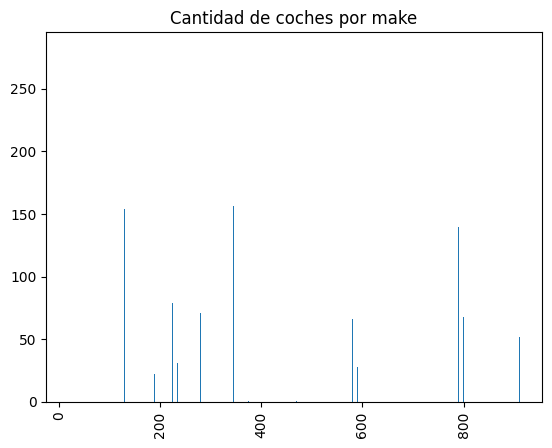

In [952]:
plt.bar(data['make'].value_counts().index, data['make'].value_counts().values)
plt.xticks(rotation=90)
plt.title('Cantidad de coches por make')
plt.show()

In [953]:
print(data['make'].value_counts())

make
670    281
190    230
905    184
860    177
60     173
650    158
345    156
570    155
130    154
425    148
720    148
285    142
790    140
550     82
225     79
280     71
800     68
194     66
580     66
910     52
390     35
340     33
235     31
590     28
40      23
189     22
730     22
830     20
487     16
868     15
810     12
380     11
560      8
20       6
820      6
504      5
375      1
470      1
242      1
Name: count, dtype: Int64


In [954]:
df_makes_precio_medio = data.groupby(['make'])['price'].mean().reset_index()
df_makes_precio_medio

,make,price
0,20,17932.333333
1,40,20799.000000
2,60,21215.763006
3,130,22323.675325
4,189,27499.000000
5,190,11541.173913
6,194,13230.818182
7,225,14349.632911
8,235,17157.064516
9,242,25799.000000


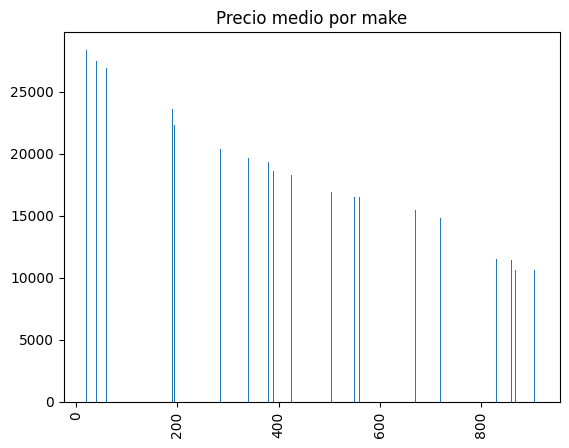

In [955]:
plt.bar(df_makes_precio_medio['make'], df_makes_precio_medio['price'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Precio medio por make')
plt.show()

In [956]:
df_makes_kms_medios = data.groupby(['make'])['kms'].mean().reset_index()

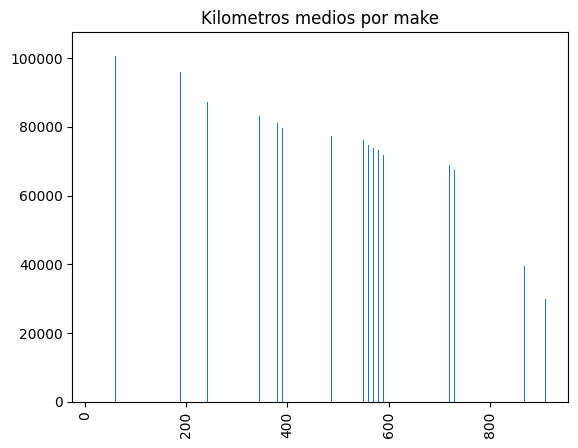

In [957]:
plt.bar(df_makes_kms_medios['make'], df_makes_kms_medios['kms'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Kilometros medios por make')
plt.show()

In [958]:
data[data['make'] == 'Abarth']

,registration,kms,gear_type,fuel_type,power,price,version,model,make


In [959]:
data['registration'] = pd.to_datetime(data['registration'], format='%m/%Y')
data.info()

<class 'pandas.DataFrame'>
Index: 3026 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   registration  3026 non-null   datetime64[us]
 1   kms           3026 non-null   int64         
 2   gear_type     3026 non-null   str           
 3   fuel_type     3026 non-null   str           
 4   power         3026 non-null   int64         
 5   price         3026 non-null   int64         
 6   version       3026 non-null   Int64         
 7   model         3026 non-null   Int64         
 8   make          3026 non-null   Int64         
dtypes: Int64(3), datetime64[us](1), int64(3), str(2)
memory usage: 245.3 KB


In [960]:
df_groupby_model = data.groupby(['model', 'make']).agg({
    'kms': 'mean', 
    'power': 'mean', 
    'registration': 'mean', 
    'price': 'mean'
}).reset_index()
df_groupby_model

,model,make,kms,power,registration,price
0,2,20,30445.500000,162.000000,2021-05-16 12:00:00.000000,20449.000000
1,5,20,86181.000000,152.500000,2019-12-31 12:00:00.000000,14799.000000
2,6,20,100392.000000,180.000000,2019-05-01 00:00:00.000000,15499.000000
3,8,20,31198.000000,179.000000,2022-11-01 00:00:00.000000,21599.000000
4,42,40,95908.750000,182.500000,2020-08-31 00:00:00.000000,23049.000000
...,...,...,...,...,...,...
305,1514,910,132424.000000,190.000000,2020-09-01 00:00:00.000000,24999.000000
306,1515,910,148911.000000,190.000000,2019-04-01 00:00:00.000000,22999.000000
307,1516,910,81929.200000,188.200000,2020-09-06 10:48:00.000000,25049.000000
308,1517,910,106453.384615,227.076923,2020-02-28 01:50:46.153846,26799.000000


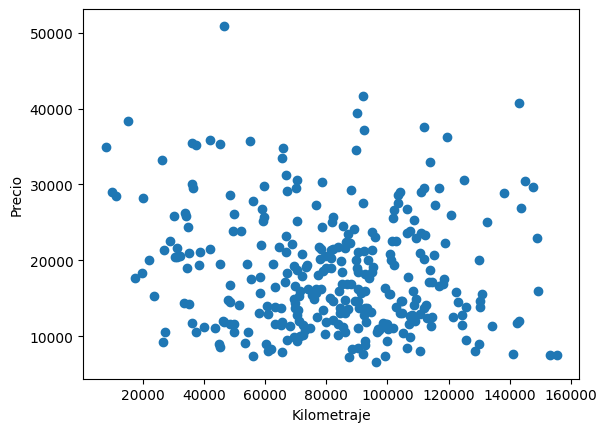

In [961]:
plt.scatter(x=df_groupby_model['kms'], y=df_groupby_model['price'])
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

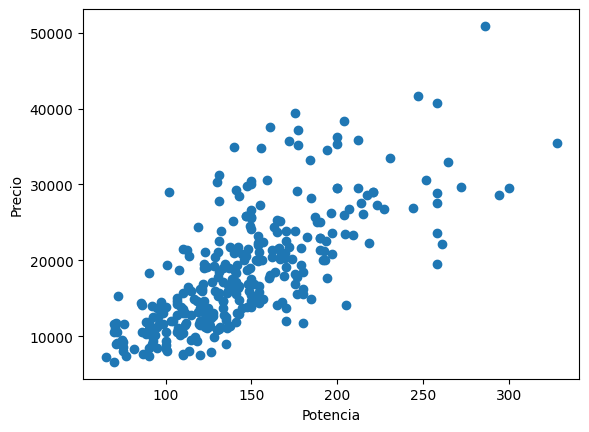

In [962]:
plt.scatter(x=df_groupby_model['power'], y=df_groupby_model['price'])
plt.xlabel('Potencia')
plt.ylabel('Precio')
plt.show()

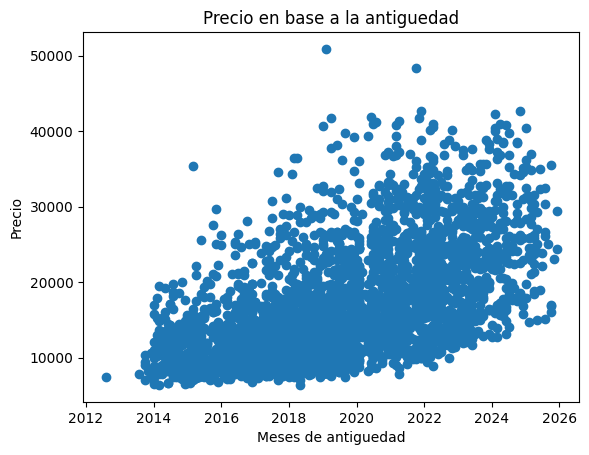

In [963]:
plt.scatter(x=data['registration'], y=data['price'])
plt.title('Precio en base a la antiguedad')
plt.xlabel('Meses de antiguedad')
plt.ylabel('Precio')
plt.show()

In [964]:
# Transformamos las columnas categoricas
le_gear = LabelEncoder()
le_fuel = LabelEncoder()

df_final['gear_type'] = le_gear.fit_transform(df_final['gear_type']) + 1
df_final['fuel_type'] = le_fuel.fit_transform(df_final['fuel_type']) + 1

hoy = pd.Timestamp.now()
df_final['antiguedad_meses'] = ((hoy.year - data['registration'].dt.year) * 12 + (hoy.month - data['registration'].dt.month))

# Eliminamos la columna original de fecha porque el modelo no la entiende
df_final = df_final.drop(columns=['registration'])


In [965]:
df_final.head()

,kms,gear_type,fuel_type,power,price,version,model,make,antiguedad_meses
0,17222,3,1,128,12599,3458,694,425,143
1,32462,1,3,265,40999,3554,723,425,25
2,78068,3,1,150,17299,6159,1127,670,94
3,19060,1,3,218,39999,4645,898,570,27
4,94982,3,1,100,9399,1551,277,190,115


Text(0.5, 1.0, 'Outliers de Kilómetros')

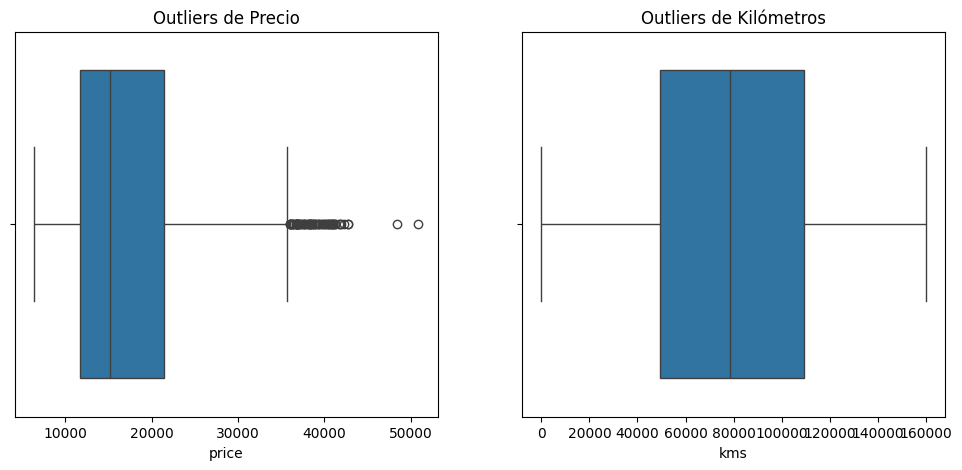

In [966]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=data['price'])
plt.title('Outliers de Precio')

# Gráfico para kms
plt.subplot(1, 2, 2)
sns.boxplot(x=data['kms'])
plt.title('Outliers de Kilómetros')

In [967]:
#  Vemos el porcentaje de outliers
print(df_final[df_final['price'] > 36000]['price'].count())
total_outliers = len(df_final[df_final['price'] > 36000])
porcentaje = (total_outliers / len(df_final)) * 100
print(f"Porcentaje de outliers en price: {porcentaje}")

63
Porcentaje de outliers en price: 2.081956378056841


In [968]:
df_final = df_final[df_final['price'] <= 36000]

Text(0.5, 1.0, 'Outliers de Precio')

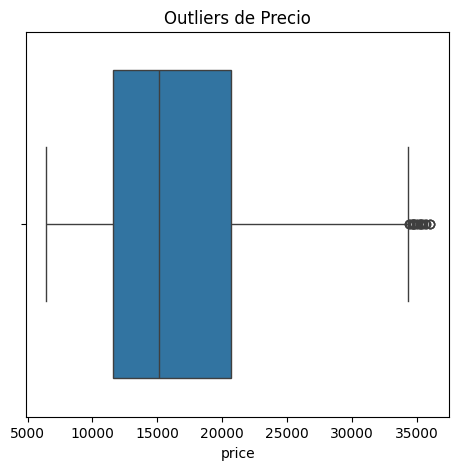

In [969]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=df_final['price'])
plt.title('Outliers de Precio')

In [970]:
# Exportamos el dataset
df_clean = data[data['price'] <= 36000].drop(columns=['antiguedad_meses'])

In [971]:
orden_df = [
    'make',
    'model',
    'version',
    'gear_type',
    'fuel_type',
    'power',
    'kms',
    'registration',
    'price'
]

In [972]:
df_clean = df_clean[orden_df]
df_clean.head()

,make,model,version,gear_type,fuel_type,power,kms,registration,price
0,425,694,3458,3,1,128,17222,2014-06-01,12599
2,670,1127,6159,3,1,150,78068,2018-07-01,17299
4,190,277,1551,3,1,100,94982,2016-10-01,9399
5,790,1235,6913,3,2,116,7628,2025-03-01,22999
6,830,1320,7273,1,2,83,30872,2023-09-01,16999


In [973]:
# División de datos
X = df_final.drop(columns='price')
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [974]:
X.info()

<class 'pandas.DataFrame'>
Index: 2963 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   kms               2963 non-null   int64
 1   gear_type         2963 non-null   int64
 2   fuel_type         2963 non-null   int64
 3   power             2963 non-null   int64
 4   version           2963 non-null   Int64
 5   model             2963 non-null   Int64
 6   make              2963 non-null   Int64
 7   antiguedad_meses  2963 non-null   int32
dtypes: Int64(3), int32(1), int64(4)
memory usage: 205.4 KB


In [975]:
# Entrenamiento del modelo
# Como es calcular un precio, usaremos una regresión
model = XGBRegressor(n_estimators=450, learning_rate=0.07, max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [976]:
# Para calcular el MAE real, revertimos con expm1 de numpy
preds_log = model.predict(X_test)

mae = mean_absolute_error(y_test, preds_log)
r2 = r2_score(y_test, preds_log)

print(f"MAE: {mae}")
print(f"R2: {r2}")

MAE: 1363.270263671875
R2: 0.9144874811172485


In [977]:
# Calcular el error relativo
error_relativo = (mae / df_final['price'].mean()) * 100

print(f"Error relativo: {error_relativo}")

Error relativo: 8.167828208424147


In [978]:
# Guardar modelo
if not os.path.exists('../ai_models'):
    os.makedirs('../ai_models')

if not os.path.exists('../ai_models/compra_coches'):
    os.makedirs('../ai_models/compra_coches')

# Guardar modelo
joblib.dump(model, '../ai_models/compra_coches/modelo_compra_coches_iberia.pkl')

# Guardr lista de columnas de los datos a entrenar
encoders = {
    'le_gear': le_gear,
    'le_fuel': le_fuel,
    'features_names': df_final.drop(columns=['price']).columns.tolist()
}
joblib.dump(encoders, '../ai_models/compra_coches/transformadores.pkl')

['../ai_models/compra_coches/transformadores.pkl']

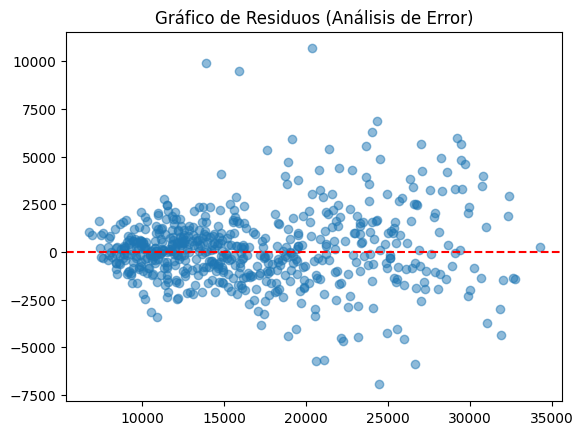

In [979]:
error = y_test - model.predict(X_test)
plt.scatter(model.predict(X_test), error, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Gráfico de Residuos (Análisis de Error)')
plt.show()

In [980]:
df_clean['is_prediction'] = False
df_clean['rep_id'] = 1

df_clean.to_csv('../datasets/coches_clean.csv', index=False)

In [981]:
fuel_bbdd = {
    'id': range(1, len(le_fuel.classes_) + 1),
    'nombre': le_fuel.classes_
}
pd.DataFrame(fuel_bbdd).to_csv('../datasets/seed_fuel_types.csv', index=False)

In [982]:
fuel_bbdd = {
    'id': range(1, len(le_gear.classes_) + 1),
    'nombre': le_gear.classes_
}
pd.DataFrame(fuel_bbdd).to_csv('../datasets/seed_gear_types.csv', index=False)

In [983]:
df_marcas = df_marcas.rename(columns={
    'marca_id': 'id',
    'nombre_marca': 'nombre'
})

df_modelos = df_modelos.rename(columns={
    'modelo_id': 'id',
    'nombre_modelo': 'nombre',
    'marca_id': 'id_marca',
})

df_modelos = df_modelos.drop('id_web', axis=1)

df_versiones = df_versiones.rename(columns={
    'version_id': 'id',
    'clave_motor': 'nombre',
    'modelo_id': 'id_modelo',
})

df_versiones = df_versiones.drop('nombre_completo', axis=1)

In [984]:
df_versiones.to_csv('../datasets/seed_versiones_bbdd.csv', index=False)
df_modelos.to_csv('../datasets/seed_modelos_bbdd.csv', index=False)
df_marcas.to_csv('../datasets/seed_marcas_bbdd.csv', index=False)